In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [16]:
df = pd.read_csv("final_data.csv")


In [17]:
df["movie_revenue"] = df["movie_revenue"].fillna(0)

In [20]:
# Drop text columns and the target
text_columns = ['movie_title', 'Publisher', 'Authors']
X = df.drop(['movie_revenue'] + text_columns, axis=1)
y = df['movie_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

RMSE: 36,175,541.63
R² Score: 0.9888


In [21]:
#checking for overfitting
train_predictions = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
print(f"Training RMSE: {train_rmse:,.2f}")
print(f"Test RMSE: {rmse:,.2f}")

Training RMSE: 1,016,790.64
Test RMSE: 36,175,541.63


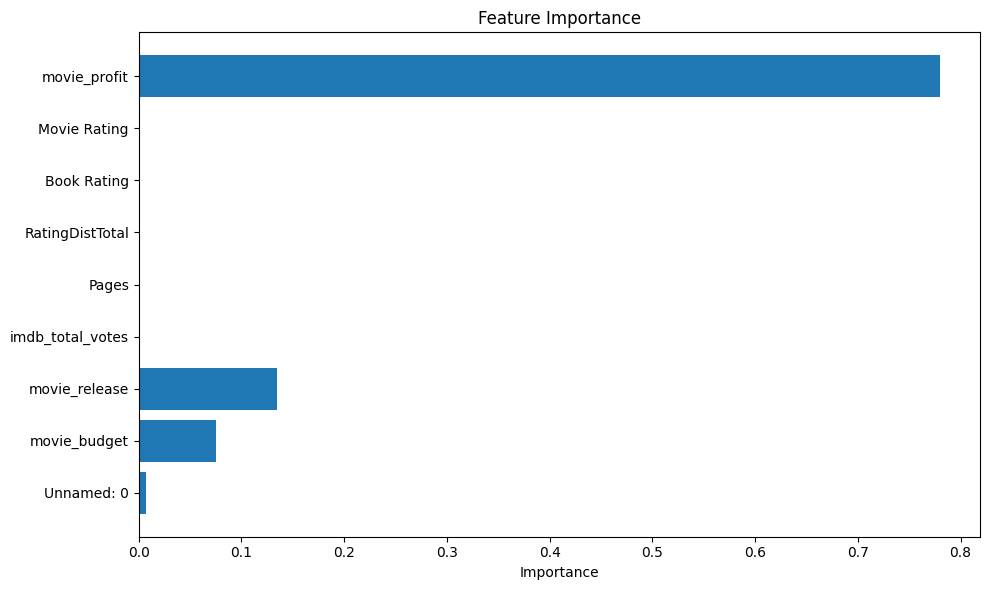

In [22]:
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

<p>Huge overfititng + answers are dep on profit - which is dep on revenue </p>

In [23]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Drop text columns, target, AND profit (data leakage!)
columns_to_drop = ['movie_revenue', 'movie_title', 'Publisher', 'Authors', 'movie_profit']
X = df.drop(columns_to_drop, axis=1, errors='ignore')  # errors='ignore' in case profit column has different name
y = df['movie_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Reduce model complexity to prevent overfitting
model = XGBRegressor(
    n_estimators=100,        # Reduced from 300
    max_depth=4,             # Reduced from 6
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,    # Added: use 80% of features per tree
    reg_alpha=1,             # Added: L1 regularization
    reg_lambda=1,            # Added: L2 regularization
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

print(f"Training RMSE: {train_rmse:,.2f}")
print(f"Test RMSE: {test_rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\nOverfitting ratio: {test_rmse/train_rmse:.2f}x")

Training RMSE: 38,278,422.59
Test RMSE: 169,592,805.51
R² Score: 0.7530

Overfitting ratio: 4.43x


<p>Overfitting is better but performance dropped</p>

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Step 1: Define what makes a movie a "hit" vs "flop"
# Let's say a hit is when profit > 0 (you can adjust this threshold)
df['is_hit'] = (df['movie_profit'] > 0).astype(int)  # 1 = hit, 0 = flop

# Alternative thresholds you could try:
# df['is_hit'] = (df['movie_revenue'] > df['movie_budget'] * 2).astype(int)  # 2x budget
# df['is_hit'] = (df['movie_profit'] > df['movie_budget'] * 0.5).astype(int)  # 50% profit margin

# Step 2: Select features (NO revenue or profit - those would be cheating!)
features_to_use = [
    'movie_budget',
    'movie_release',      # Release year might matter
    'imdb_total_votes',   # Popularity of source material
    'Pages',              # Book length
    'RatingDistTotal',    
    'Book Rating',        # Quality of source material
    'Movie Rating'        # If you have this BEFORE release, otherwise drop it
]

X = df[features_to_use]
y = df['is_hit']

# Check class distribution
print("Class distribution:")
print(y.value_counts())
print(f"\nHit rate: {y.mean()*100:.1f}%")

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Keep same hit/flop ratio in train and test
)

# Step 4: Train classifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# Step 5: Evaluate
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=['Flop', 'Hit']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

# Feature importance
import matplotlib.pyplot as plt
importance_df = pd.DataFrame({
    'feature': features_to_use,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

Class distribution:
is_hit
0    2777
1     488
Name: count, dtype: int64

Hit rate: 14.9%

Training Accuracy: 0.9989
Test Accuracy: 0.9372

Classification Report:
              precision    recall  f1-score   support

        Flop       0.97      0.96      0.96       555
         Hit       0.78      0.82      0.80        98

    accuracy                           0.94       653
   macro avg       0.87      0.89      0.88       653
weighted avg       0.94      0.94      0.94       653


Confusion Matrix:
[[532  23]
 [ 18  80]]

Feature Importance:
            feature  importance
0      movie_budget    0.408985
2  imdb_total_votes    0.316330
1     movie_release    0.069853
6      Movie Rating    0.052776
4   RatingDistTotal    0.051925
3             Pages    0.051132
5       Book Rating    0.049001


<p>We have overfitting + data leakage</p>

In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Step 1: Define hit/flop
df['is_hit'] = (df['movie_profit'] > 0).astype(int)

# Step 2: Features WITHOUT Movie Rating (that's post-release data)
features_to_use = [
    'movie_budget',
    'movie_release',
    'imdb_total_votes',
    'Pages',
    'RatingDistTotal',
    'Book Rating'
    # Removed 'Movie Rating' - that's after release!
]

X = df[features_to_use]
y = df['is_hit']

print("Class distribution:")
print(y.value_counts())
print(f"Hit rate: {y.mean()*100:.1f}%\n")

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Step 4: Train with reduced complexity to prevent overfitting
model = XGBClassifier(
    n_estimators=100,      # Reduced from 200
    max_depth=3,           # Reduced from 4 (shallower trees)
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,           # L1 regularization
    reg_lambda=1,          # L2 regularization
    scale_pos_weight=5.7,  # Balance classes (2777/488 ≈ 5.7)
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# Step 5: Evaluate
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Overfitting gap: {(train_acc - test_acc)*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, test_pred, target_names=['Flop', 'Hit']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, test_pred)
print(cm)

# Calculate useful metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correctly predicted flops): {tn}")
print(f"False Positives (predicted hit, was flop): {fp}")
print(f"False Negatives (predicted flop, was hit): {fn}")
print(f"True Positives (correctly predicted hits): {tp}")

# Feature importance
importance_df = pd.DataFrame({
    'feature': features_to_use,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

Class distribution:
is_hit
0    2777
1     488
Name: count, dtype: int64
Hit rate: 14.9%

Training Accuracy: 0.9361
Test Accuracy: 0.9280
Overfitting gap: 0.80%

Classification Report:
              precision    recall  f1-score   support

        Flop       0.99      0.92      0.96       555
         Hit       0.69      0.95      0.80        98

    accuracy                           0.93       653
   macro avg       0.84      0.94      0.88       653
weighted avg       0.95      0.93      0.93       653

Confusion Matrix:
[[513  42]
 [  5  93]]

True Negatives (correctly predicted flops): 513
False Positives (predicted hit, was flop): 42
False Negatives (predicted flop, was hit): 5
True Positives (correctly predicted hits): 93

Feature Importance:
            feature  importance
0      movie_budget    0.632922
2  imdb_total_votes    0.233457
1     movie_release    0.039845
3             Pages    0.033408
5       Book Rating    0.030693
4   RatingDistTotal    0.029676


<p>Overfitting almost gone. No data leakage. 92.8% test accuracy. 95% hit recall.</p>

In [26]:
import pickle
with open('movie_hit_predictor.pkl', 'wb') as f:
    pickle.dump(model, f)

In [27]:
# Example: predict for a new movie
new_movie = pd.DataFrame({
    'movie_budget': [50000000],
    'movie_release': [2025],
    'imdb_total_votes': [10000],
    'Pages': [350],
    'RatingDistTotal': [5000],
    'Book Rating': [4.2]
})

prediction = model.predict(new_movie)
probability = model.predict_proba(new_movie)

print(f"Prediction: {'HIT' if prediction[0] == 1 else 'FLOP'}")
print(f"Confidence: {probability[0][prediction[0]]*100:.1f}%")

Prediction: FLOP
Confidence: 79.0%


In [28]:
# Get probabilities instead of hard predictions
probs = model.predict_proba(X_test)[:, 1]

# Try different thresholds
for threshold in [0.3, 0.5, 0.7]:
    preds = (probs >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, preds, target_names=['Flop', 'Hit']))


Threshold: 0.3
              precision    recall  f1-score   support

        Flop       1.00      0.90      0.95       555
         Hit       0.64      0.98      0.77        98

    accuracy                           0.91       653
   macro avg       0.82      0.94      0.86       653
weighted avg       0.94      0.91      0.92       653


Threshold: 0.5
              precision    recall  f1-score   support

        Flop       0.99      0.92      0.96       555
         Hit       0.69      0.95      0.80        98

    accuracy                           0.93       653
   macro avg       0.84      0.94      0.88       653
weighted avg       0.95      0.93      0.93       653


Threshold: 0.7
              precision    recall  f1-score   support

        Flop       0.98      0.94      0.96       555
         Hit       0.74      0.91      0.81        98

    accuracy                           0.94       653
   macro avg       0.86      0.93      0.89       653
weighted avg       0.95   